## **Single Layer Perceptron Implementation Assignment**
Melinda Annastasia Budijono - 24/54280/PA/23052



**Deskripsi Proyek**

Notebook ini berisi implementasi **Single Layer Perceptron** yang dibangun secara matematis dari awal menggunakan bantuan *library* Numpy. Model ini dilatih menggunakan metode *Gradient Descent* untuk meminimalkan *Sum Squared Error* (SSE).



**Informasi Dataset**

Dataset yang digunakan adalah varian dari dataset bunga Iris dengan rincian sebagai berikut:
* **Fitur (Input):** Memiliki 4 variabel numerik (`X1`, `X2`, `X3`, `X4`).
* **Target (Label):** Klasifikasi biner yang dipetakan menjadi dua kelas utama:
  * `0` : Iris-setosa
  * `1` : Iris-versicolor

---
#### **1. Import Library & Persiapan Data**
Memuat library yang dibutuhkan, membaca satu dataset utuh (dengan penanganan baris *error*), memetakan label target, serta memisahkan dataset menjadi set *training* dan *validation* secara terstruktur (mengambil tepat 10 data terakhir dari masing-masing kelas untuk divalidasi).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('dataset/dataset.csv')
 
label_map = {"Iris-setosa": 0, "Iris-versicolor": 1}
df["Target"] = df["Target"].map(label_map)

df_0 = df[df["Target"] == 0]
df_1 = df[df["Target"] == 1]

train_0, val_0 = df_0.iloc[:-10], df_0.iloc[-10:]
train_1, val_1 = df_1.iloc[:-10], df_1.iloc[-10:]

train_df = pd.concat([train_0, train_1])
val_df = pd.concat([val_0, val_1])

x_train = train_df[["X1", "X2", "X3", "X4"]].to_numpy()
y_train = train_df["Target"].to_numpy()
x_val = val_df[["X1", "X2", "X3", "X4"]].to_numpy()
y_val = val_df["Target"].to_numpy()

print(f"Total data Training: {len(train_df)} baris")
print(train_df["Target"].value_counts())
display(train_df.head(3))
display(train_df.tail(3))

print(f"Total data Validation: {len(val_df)} baris")
display(val_df.head(3))
display(val_df.tail(3))

Total data Training: 80 baris
Target
0    40
1    40
Name: count, dtype: int64


,X1,X2,X3,X4,Target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


,X1,X2,X3,X4,Target
87,6.3,2.3,4.4,1.3,1
88,5.6,3.0,4.1,1.3,1
89,5.5,2.5,4.0,1.3,1


Total data Validation: 20 baris


,X1,X2,X3,X4,Target
40,5.0,3.5,1.3,0.3,0
41,4.5,2.3,1.3,0.3,0
42,4.4,3.2,1.3,0.2,0


,X1,X2,X3,X4,Target
97,6.2,2.9,4.3,1.3,1
98,5.1,2.5,3.0,1.1,1
99,5.7,2.8,4.1,1.3,1


---
#### **2. Inisialisasi Parameter & Fungsi Matematis**
Menentukan *hyperparameter* awal (Learning Rate, Epochs), bobot model (*teta*), fungsi aktivasi Sigmoid, perhitungan Propagasi Maju (*Forward*), fungsi Gradien, serta fungsi khusus untuk menghitung *Error* dan *Sum Squared Error* (SSE).

In [3]:
LEARNING_RATE = 0.1
EPOCHS = 5

teta = np.array([0.5, 0.5, 0.5, 0.5, 0.5]) 

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(teta, x_row):
    x_with_bias = np.concatenate(([1.0], x_row))
    z = np.dot(teta, x_with_bias)
    g = sigmoid(z)
    return z, g, x_with_bias

def gradient(g, target):
    return 2.0 * (g - target) * g * (1.0 - g)

def calculate_error(target, g):
    error = target - g
    sse = error ** 2
    return error, sse

---
#### **3. Proses Pelatihan Model (Training)**
Mengeksekusi iterasi *training* untuk memperbarui bobot (*update weight*) berdasarkan perhitungan *error*, mencatat metrik evaluasi (SSE & Akurasi) per *epoch*, dan menyimpan bobot akhir secara tepat untuk digunakan sebagai titik awal pada iterasi selanjutnya. Untuk keterbacaan, tabel hanya menampilkan sebagian baris awal dan akhir.

In [4]:
train_history = []
teta_terakhir = {}
ringkasan_train = {}

for epoch in range(1, EPOCHS + 1):
    total_sse_train = 0
    total_benar_train = 0

    for i in range(len(x_train)):
        x_i = x_train[i]
        target = y_train[i]

        z, g, x_with_bias = forward(teta, x_i)
        prediksi = 1 if g >= 0.5 else 0
        error, sse = calculate_error(target, g)

        total_sse_train += sse
        if prediksi == target:
            total_benar_train += 1

        train_history.append({
            "Epoch": epoch,
            "Target": target,
            "bias": teta[0],    
            "teta1": teta[1],
            "teta2": teta[2],
            "teta3": teta[3],
            "teta4": teta[4],
            "z": z,
            "g(z)": g,
            "Prediksi": prediksi,
            "Error": error,
            "SSE": sse
        })
    
        dz = gradient(g, target)
        teta = teta - LEARNING_RATE * dz * x_with_bias
    teta_terakhir[epoch] = teta.copy()

    ringkasan_train[epoch] = {
        "Train Accuracy": total_benar_train / len(x_train),
        "Train Avg SSE": total_sse_train / len(x_train)
    }
    
train_python = pd.DataFrame(train_history)
print(f"Total baris hasil training: {len(train_python)} ({EPOCHS} epoch x {len(x_train)} sampel)")
print("\nNilai Teta Terakhir di Setiap Epoch")
for ep, t in teta_terakhir.items():    print(f"Epoch {ep}: {t}")

Total baris hasil training: 400 (5 epoch x 80 sampel)

Nilai Teta Terakhir di Setiap Epoch
Epoch 1: [ 0.38033612 -0.01913312  0.07144656  0.52444933  0.55114017]
Epoch 2: [ 0.34247243 -0.09319455 -0.07615825  0.7072215   0.63643854]
Epoch 3: [ 0.31041811 -0.15226599 -0.2037863   0.86571089  0.70933991]
Epoch 4: [ 0.28227383 -0.20186001 -0.3181515   1.00254085  0.77078769]
Epoch 5: [ 0.25771975 -0.24180165 -0.41690349  1.1222139   0.82405866]


In [5]:
for epoch in range(1, EPOCHS + 1):
    print(f"\nEPOCH {epoch} — Hasil Training")
    epoch_table = train_python[train_python["Epoch"] == epoch].reset_index(drop=True)

    tabel_singkat = pd.concat([epoch_table.head(3), epoch_table.tail(3)])
    display(tabel_singkat)

    ringkasan = ringkasan_train[epoch]
    print(f"Ringkasan Epoch {epoch}:")
    print(f"Akurasi: {ringkasan['Train Accuracy']} | Rata-rata SSE: {ringkasan['Train Avg SSE']}")


EPOCH 1 — Hasil Training


,Epoch,Target,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,1,0,0.500000,0.500000,0.500000,0.500000,0.500000,5.600000,0.996316,1,-0.996316,0.992645
1,1,0,0.499269,0.496270,0.497440,0.498976,0.499854,5.221847,0.994632,1,-0.994632,0.989292
2,1,0,0.498206,0.491065,0.494253,0.497489,0.499641,5.134487,0.994144,1,-0.994144,0.988323
77,1,1,0.379636,-0.023165,0.069621,0.521547,0.550231,3.403931,0.967827,1,0.032173,0.001035
78,1,1,0.379837,-0.021903,0.070082,0.522429,0.550491,3.325022,0.965277,1,0.034723,0.001206
79,1,1,0.380070,-0.020599,0.070780,0.523383,0.550794,3.253286,0.962791,1,0.037209,0.001385


Ringkasan Epoch 1:
Akurasi: 0.525 | Rata-rata SSE: 0.4498886551395292

EPOCH 2 — Hasil Training


,Epoch,Target,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,2,0,0.380336,-0.019133,0.071447,0.524449,0.551140,1.377277,0.798553,1,-0.798553,0.637687
1,2,0,0.354644,-0.150162,-0.018475,0.488481,0.546002,0.356496,0.588192,1,-0.588192,0.345970
2,2,0,0.326149,-0.289786,-0.103959,0.448588,0.540303,-0.677289,0.336867,0,-0.336867,0.113479
77,2,1,0.341797,-0.097076,-0.077938,0.704423,0.635560,3.476650,0.970016,1,0.029984,0.000899
78,2,1,0.341971,-0.095978,-0.077536,0.705191,0.635787,3.289692,0.964074,1,0.035926,0.001291
79,2,1,0.342220,-0.094584,-0.076790,0.706211,0.636110,3.281822,0.963800,1,0.036200,0.001310


Ringkasan Epoch 2:
Akurasi: 0.95 | Rata-rata SSE: 0.0374519142280995

EPOCH 3 — Hasil Training


...

Ringkasan Epoch 3:
Akurasi: 0.975 | Rata-rata SSE: 0.02437219499639378

EPOCH 4 — Hasil Training


,Epoch,Target,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,4,0,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.174473,0.543508,1,-0.543508,0.295401
1,4,0,0.283448,-0.289811,-0.298180,0.827953,0.703946,-0.731242,0.324922,0,-0.324922,0.105574
2,4,0,0.269194,-0.359657,-0.340943,0.807998,0.701095,-1.321592,0.210553,0,-0.210553,0.044333
77,4,1,0.281687,-0.205212,-0.319720,1.000118,0.770025,3.655047,0.974792,1,0.025208,0.000635
78,4,1,0.281811,-0.204432,-0.319435,1.000664,0.770186,3.282650,0.963829,1,0.036171,0.001308
79,4,1,0.282063,-0.203019,-0.318679,1.001698,0.770514,3.377218,0.966985,1,0.033015,0.001090


Ringkasan Epoch 4:
Akurasi: 0.975 | Rata-rata SSE: 0.0173572016784266

EPOCH 5 — Hasil Training


,Epoch,Target,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,5,0,0.282274,-0.201860,-0.318152,1.002541,0.770788,-0.303028,0.424817,0,-0.424817,0.180470
1,5,0,0.261513,-0.307739,-0.390814,0.973476,0.766636,-0.902657,0.288505,0,-0.288505,0.083235
2,5,0,0.249669,-0.365776,-0.426347,0.956894,0.764267,-1.436972,0.192015,0,-0.192015,0.036870
77,5,1,0.257184,-0.244856,-0.418345,1.120005,0.823362,3.750790,0.977040,1,0.022960,0.000527
78,5,1,0.257287,-0.244207,-0.418108,1.120458,0.823496,3.299827,0.964423,1,0.035577,0.001266
79,5,1,0.257531,-0.242840,-0.417375,1.121459,0.823813,3.435267,0.968789,1,0.031211,0.000974


Ringkasan Epoch 5:
Akurasi: 0.9875 | Rata-rata SSE: 0.012740158208926553


---
#### **4. Proses Validasi Model (Validation)**
Menguji performa model pada data validasi menggunakan bobot final (`teta_terakhir`) yang dihasilkan dari masing-masing *epoch* pada tahap *training*.

In [6]:
val_history = []
ringkasan_val = {}

for epoch in range(1, EPOCHS + 1):
    total_sse_val = 0
    total_benar_val = 0
    teta = teta_terakhir[epoch]

    for i in range(len(x_val)):
        x_i = x_val[i]
        target = y_val[i]

        z, g, x_with_bias = forward(teta, x_i)
        prediksi = 1 if g >= 0.5 else 0
        error, sse = calculate_error(target, g)

        total_sse_val += sse
        if prediksi == target:
            total_benar_val += 1

        val_history.append({
            "Epoch": epoch,
            "TARGET": target,
            "bias": teta[0],
            "teta1": teta[1],
            "teta2": teta[2],
            "teta3": teta[3],
            "teta4": teta[4],
            "z": z,
            "g(z)": g,
            "Prediksi": prediksi,
            "Error": error,
            "SSE": sse
        })

    ringkasan_val[epoch] = {
        "Val Accuracy": total_benar_val / len(x_val),
        "Val Avg SSE": total_sse_val / len(x_val)
    }

val_python = pd.DataFrame(val_history)
print(f"Total baris hasil validasi: {len(val_python)}  ({EPOCHS} epoch x {len(x_val)} sampel)")

Total baris hasil validasi: 100  (5 epoch x 20 sampel)


In [7]:
for epoch in range(1, EPOCHS + 1):
    print(f"\nEPOCH {epoch} — Hasil Validation")
    epoch_table = val_python[val_python["Epoch"] == epoch].reset_index(drop=True)

    tabel_singkat = pd.concat([epoch_table.head(3), epoch_table.tail(3)])
    display(tabel_singkat)

    ringkasan = ringkasan_val[epoch]
    print(f"\nRingkasan Epoch {epoch}:")
    print(f"Akurasi: {ringkasan['Val Accuracy']} | Rata-rata SSE: {ringkasan['Val Avg SSE']}")


EPOCH 1 — Hasil Validation


,Epoch,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,1,0,0.380336,-0.019133,0.071447,0.524449,0.55114,1.381860,0.799289,1,-0.799289,0.638864
1,1,0,0.380336,-0.019133,0.071447,0.524449,0.55114,1.305690,0.786791,1,-0.786791,0.619040
2,1,0,0.380336,-0.019133,0.071447,0.524449,0.55114,1.316792,0.788647,1,-0.788647,0.621965
17,1,1,0.380336,-0.019133,0.071447,0.524449,0.55114,3.440520,0.968947,1,0.031053,0.000964
18,1,1,0.380336,-0.019133,0.071447,0.524449,0.55114,2.640976,0.933453,1,0.066547,0.004429
19,1,1,0.380336,-0.019133,0.071447,0.524449,0.55114,3.338052,0.965711,1,0.034289,0.001176



Ringkasan Epoch 1:
Akurasi: 0.5 | Rata-rata SSE: 0.3289511565546992

EPOCH 2 — Hasil Validation


,Epoch,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,2,0,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.720265,0.672665,1,-0.672665,0.452479
1,2,0,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.858253,0.702295,1,-0.702295,0.493219
2,2,0,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.735386,0.675986,1,-0.675986,0.456957
17,2,1,0.342472,-0.093195,-0.076158,0.707221,0.636439,3.412230,0.968085,1,0.031915,0.001019
18,2,1,0.342472,-0.093195,-0.076158,0.707221,0.636439,2.498532,0.924039,1,0.075961,0.005770
19,2,1,0.342472,-0.093195,-0.076158,0.707221,0.636439,3.324999,0.965277,1,0.034723,0.001206



Ringkasan Epoch 2:
Akurasi: 0.5 | Rata-rata SSE: 0.24728932330356238

EPOCH 3 — Hasil Validation


...


Ringkasan Epoch 3:
Akurasi: 0.5 | Rata-rata SSE: 0.1758916406671348

EPOCH 4 — Hasil Validation


,Epoch,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,4,0,0.282274,-0.20186,-0.318152,1.002541,0.770788,-0.306017,0.424087,0,-0.424087,0.179850
1,4,0,0.282274,-0.20186,-0.318152,1.002541,0.770788,0.176695,0.544059,1,-0.544059,0.296000
2,4,0,0.282274,-0.20186,-0.318152,1.002541,0.770788,-0.166534,0.458462,0,-0.458462,0.210188
17,4,1,0.282274,-0.20186,-0.318152,1.002541,0.770788,3.421052,0.968356,1,0.031644,0.001001
18,4,1,0.282274,-0.20186,-0.318152,1.002541,0.770788,2.312898,0.909940,1,0.090060,0.008111
19,4,1,0.282274,-0.20186,-0.318152,1.002541,0.770788,3.353289,0.966212,1,0.033788,0.001142



Ringkasan Epoch 4:
Akurasi: 0.85 | Rata-rata SSE: 0.1193813732929732

EPOCH 5 — Hasil Validation


,Epoch,TARGET,bias,teta1,teta2,teta3,teta4,z,g(z),Prediksi,Error,SSE
0,5,0,0.25772,-0.241802,-0.416903,1.122214,0.824059,-0.704355,0.330847,0,-0.330847,0.109460
1,5,0,0.25772,-0.241802,-0.416903,1.122214,0.824059,-0.083170,0.479219,0,-0.479219,0.229651
2,5,0,0.25772,-0.241802,-0.416903,1.122214,0.824059,-0.516609,0.373646,0,-0.373646,0.139611
17,5,1,0.25772,-0.241802,-0.416903,1.122214,0.824059,3.446325,0.969121,1,0.030879,0.000953
18,5,1,0.25772,-0.241802,-0.416903,1.122214,0.824059,2.255379,0.905113,1,0.094887,0.009003
19,5,1,0.25772,-0.241802,-0.416903,1.122214,0.824059,3.384474,0.967216,1,0.032784,0.001075



Ringkasan Epoch 5:
Akurasi: 1.0 | Rata-rata SSE: 0.08158136941106597


---
#### **5. Ringkasan Evaluasi per Epoch & Visualisasi**
Menyajikan tabel perbandingan performa model (Rata-rata SSE dan Akurasi) antara fase *Training* dan *Validation* dari *epoch* pertama hingga terakhir dan Memplot pergerakan metrik Error (SSE) dan Akurasi untuk mendeteksi apakah model sudah belajar dengan baik (konvergen) atau mengalami *overfitting/underfitting*.

In [8]:
summary_data = []
for epoch in range(1, EPOCHS + 1):
    summary_data.append({
        "Epoch": epoch,
        "Train Avg SSE": ringkasan_train[epoch]["Train Avg SSE"],
        "Val Avg SSE": ringkasan_val[epoch]["Val Avg SSE"],
        "Train Accuracy": ringkasan_train[epoch]["Train Accuracy"],
        "Val Accuracy": ringkasan_val[epoch]["Val Accuracy"]
    })

summary_df = pd.DataFrame(summary_data)
display(summary_df)

,Epoch,Train Avg SSE,Val Avg SSE,Train Accuracy,Val Accuracy
0,1,0.449889,0.328951,0.5250,0.50
1,2,0.037452,0.247289,0.9500,0.50
2,3,0.024372,0.175892,0.9750,0.50
3,4,0.017357,0.119381,0.9750,0.85
4,5,0.012740,0.081581,0.9875,1.00


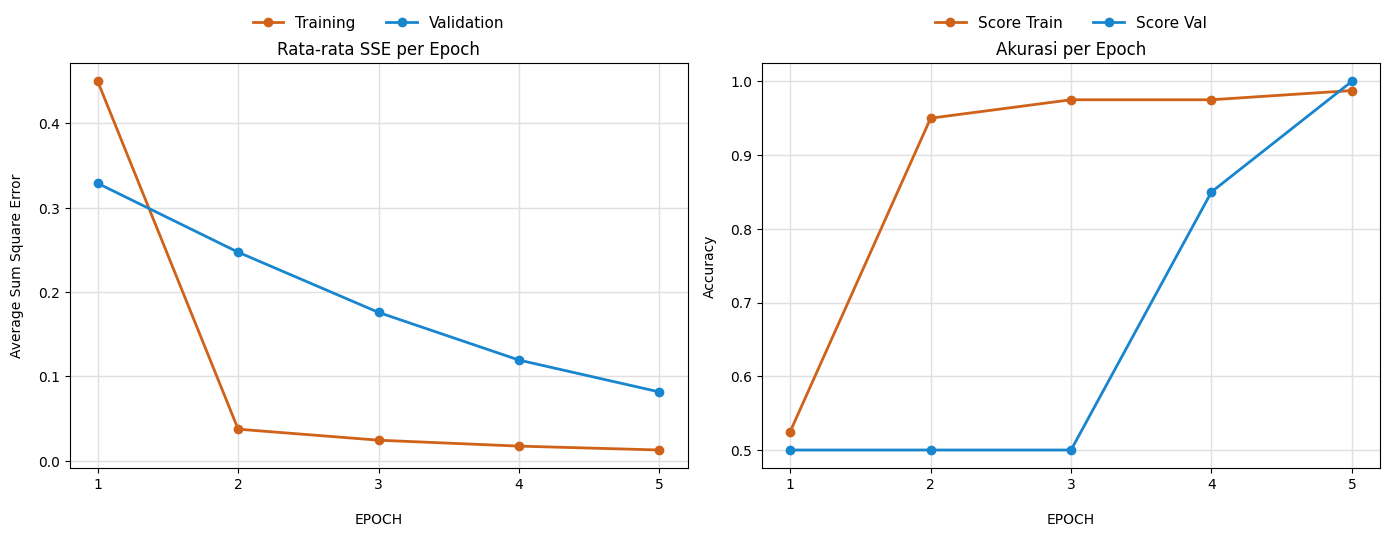

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='white')

color_train = '#cf6218'
color_val = '#1885cf'

ax1.plot(summary_df["Epoch"], summary_df["Train Avg SSE"], marker='o', markersize=6, linewidth=2, color=color_train, label='Training')
ax1.plot(summary_df["Epoch"], summary_df["Val Avg SSE"], marker='o', markersize=6, linewidth=2, color=color_val, label='Validation')
ax1.set_title("Rata-rata SSE per Epoch")
ax1.set_xlabel("EPOCH", labelpad=15)
ax1.set_ylabel("Average Sum Square Error", labelpad=10)
ax1.grid(color='#e0e0e0', linestyle='-', linewidth=1)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False, fontsize=11)

ax1.set_xticks(range(1, EPOCHS + 1))

ax2.plot(summary_df["Epoch"], summary_df["Train Accuracy"], marker='o', markersize=6, linewidth=2, color=color_train, label='Score Train')
ax2.plot(summary_df["Epoch"], summary_df["Val Accuracy"], marker='o', markersize=6, linewidth=2, color=color_val, label='Score Val')
ax2.set_title("Akurasi per Epoch")
ax2.set_xlabel("EPOCH", labelpad=15)
ax2.set_ylabel("Accuracy", labelpad=10)
ax2.grid(color='#e0e0e0', linestyle='-', linewidth=1)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False, fontsize=11)

ax2.set_xticks(range(1, EPOCHS + 1))

plt.tight_layout()
plt.savefig("grafik-perbandingan-slp.png", dpi=300, bbox_inches='tight')
plt.show()